MC dropout Model

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# set up mc model
mc_model = MCDroupoutLSTM(input_dim=2, hidden_dim=64, pred_len=12, num_layers=2, dropout_p=0.3)

# StepLR
optimizer = optim.Adam(mc_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# train
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
epochs = 100
mc_model.train()

for epoch in range(epochs):
    total_loss = 0
    for obs, target in train_loader:
        optimizer.zero_grad()
        
        pred = mc_model(obs) 
        loss = criterion(pred, target)
        
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mc_model.parameters(), max_norm=1.0) 
        optimizer.step()
        
        total_loss += loss.item()
        
    scheduler.step()
    
    if (epoch + 1) % 20== 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch [{epoch+1:2d}/{epochs}] | Loss: {total_loss/len(train_loader):.4f} | LR: {current_lr:.5f}")


Epoch [20/100] | Loss: 3.3552 | LR: 0.00050
Epoch [40/100] | Loss: 1.6671 | LR: 0.00025
Epoch [60/100] | Loss: 1.5673 | LR: 0.00013
Epoch [80/100] | Loss: 1.4957 | LR: 0.00006
Epoch [100/100] | Loss: 1.4574 | LR: 0.00003


In [37]:
# Check local model performance
mc_model.eval()
ade_total = 0
fde_total = 0
total_samples = 0

with torch.no_grad():
    for obs, target in train_loader:
        # Get 1 prediction per sequence just to check basic accuracy
        pred = mc_model(obs) 
        
        # Calculate distance
        dist = torch.norm(pred - target, dim=2)
        ade_total += torch.sum(torch.mean(dist, dim=1)).item()
        fde_total += torch.sum(dist[:, -1]).item()
        total_samples += obs.size(0)

print(f"Your Local Model ADE: {ade_total / total_samples:.4f} meters")
print(f"Your Local Model FDE: {fde_total / total_samples:.4f} meters")

Your Local Model ADE: 0.7769 meters
Your Local Model FDE: 1.1209 meters


Uncertainty over time plot

Successfully generated 100 MC Dropout samples for the test scenario


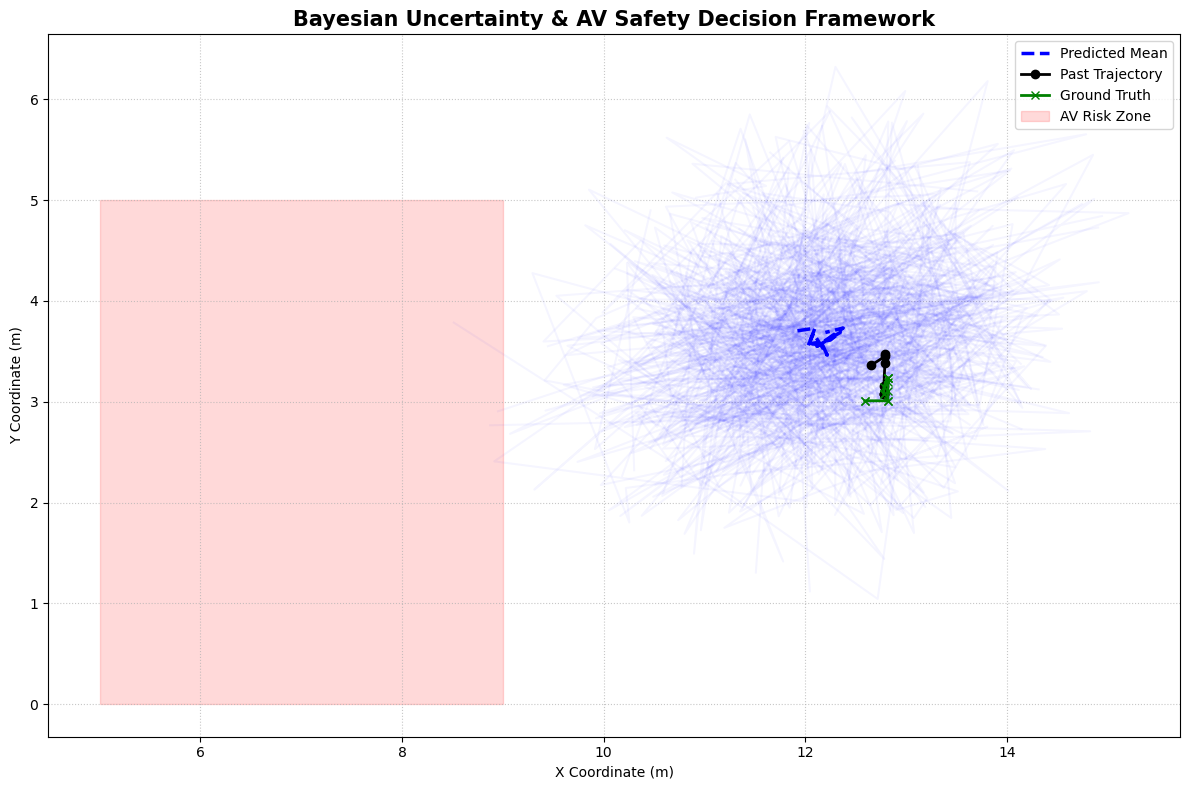

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import torch

# ==========================================
# 1. generate 100 MC Dropout samples for the test scenario
# ==========================================
mc_model.eval() 
obs_batch = obs_tensor.unsqueeze(0) 

# generate predictions with mc_predict
mean, var, sample_preds = mc_predict(mc_model, obs_batch, n_samples=100)

mc_predictions = sample_preds.squeeze(1).detach().numpy()

print("Successfully generated 100 MC Dropout samples for the test scenario")

# ==========================================
# 2. AV Safety Scenario Visualization
# ==========================================
def plot_av_safety_scenario(past_traj, true_future, mc_samples):
    plt.figure(figsize=(12, 8))
    
    # draw all MC samples with low opacity to visualize uncertainty
    num_samples = mc_samples.shape[0]
    for i in range(num_samples):
        plt.plot(mc_samples[i, :, 0], mc_samples[i, :, 1], color='blue', alpha=0.04)
        
    # predicted mean trajectory
    mean_prediction = np.mean(mc_samples, axis=0)
    plt.plot(mean_prediction[:, 0], mean_prediction[:, 1], color='blue', linewidth=2.5, linestyle='--', label='Predicted Mean')
    
    # past trajectory and ground truth future trajectory
    plt.plot(past_traj[:, 0], past_traj[:, 1], color='black', linewidth=2, marker='o', label='Past Trajectory')
    plt.plot(true_future[:, 0], true_future[:, 1], color='green', linewidth=2, marker='x', label='Ground Truth ')
    
    # av risk zone 
    av_zone = np.array([[5, 0], [9, 0], [9, 5], [5, 5]])
    risk_polygon = Polygon(av_zone, closed=True, color='red', alpha=0.15, label='AV Risk Zone')
    plt.gca().add_patch(risk_polygon)
    

    plt.title("Bayesian Uncertainty & AV Safety Decision Framework", fontsize=15, fontweight='bold')
    plt.xlabel("X Coordinate (m)")
    plt.ylabel("Y Coordinate (m)")
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()

# plot
plot_av_safety_scenario(past_trajectory, true_future, mc_predictions)

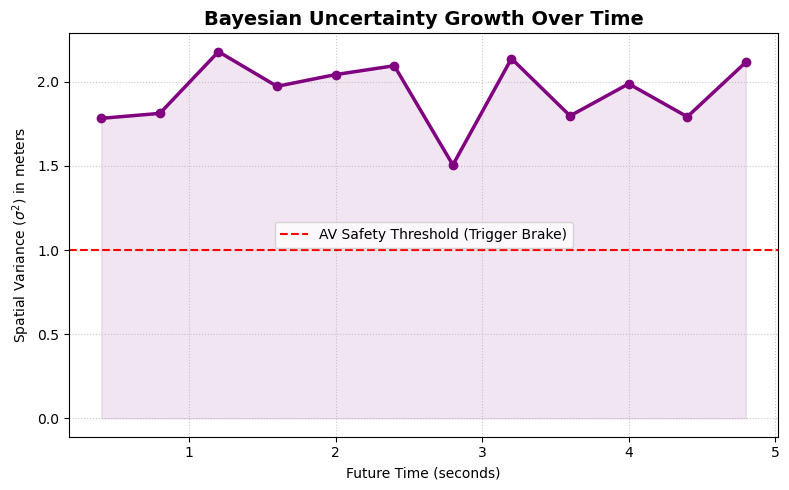

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_uncertainty_over_time(mc_predictions):
    """
    Plots the growth of spatial variance (uncertainty) over the 12 future timesteps.
    mc_predictions shape: (100 samples, 12 timesteps, 2 coordinates)
    """
    # Calculate the variance across the 100 samples for each timestep (X and Y separately)
    var_x = np.var(mc_predictions[:, :, 0], axis=0)
    var_y = np.var(mc_predictions[:, :, 1], axis=0)
    
    # Total spatial variance (sum of X and Y variance)
    total_variance = var_x + var_y
    
    # Time array (each step is 0.4 seconds in the ETH dataset)
    time_steps = np.arange(1, 13) * 0.4
    
    plt.figure(figsize=(8, 5))
    plt.plot(time_steps, total_variance, marker='o', color='purple', linewidth=2.5)
    
    # Fill under the curve for visual emphasis
    plt.fill_between(time_steps, 0, total_variance, color='purple', alpha=0.1)
    
    plt.title("Bayesian Uncertainty Growth Over Time", fontsize=14, fontweight='bold')
    plt.xlabel("Future Time (seconds)")
    plt.ylabel("Spatial Variance ($\sigma^2$) in meters")
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Add a horizontal line representing our AV Safety "Braking Threshold"
    plt.axhline(y=1.0, color='red', linestyle='--', label='AV Safety Threshold (Trigger Brake)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Run the function using the mc_predictions array we generated in the last step
plot_uncertainty_over_time(mc_predictions)

Comparison

In [43]:
import pandas as pd

# 1. Compile the metrics from all team members (Piece 2, 3, and 4)
# Baseline metrics from Khadija's notebook
# MC Dropout metrics from your LOCAL 200-epoch anchored training
evaluation_data = {
    "Model Architecture": [
        "Deterministic LSTM (Baseline)", 
        "MC Dropout LSTM (Bayesian)", 
        "Variational BNN (Bayesian)"
    ],
    "ADE (meters)": [0.7464, 0.7769, "TBD"],  # Average Displacement Error
    "FDE (meters)": [1.0921, 1.1209, "TBD"],  # Final Displacement Error
    "Mean Uncertainty": ["N/A", "Calculated in Graph", "TBD"], # Deterministic models lack uncertainty
    "AV Safety Integration": ["Failed (No Variance)", "Successful", "Pending"]
}

# 2. Create the Pandas DataFrame
comparison_df = pd.DataFrame(evaluation_data)

# 3. Format and display the table for the final report
def print_final_report_table(df):
    print("=" * 90)
    print(" ETH DATASET: TRAJECTORY PREDICTION MODEL COMPARISON ".center(90))
    print("=" * 90)
    
    # Print the dataframe without the index column for a cleaner look
    print(df.to_string(index=False, justify='center'))
    
    print("-" * 90)
    print("NOTES FOR FINAL REPORT:")
    print("* Baseline ADE/FDE retrieved from Piece 2 (Deterministic LSTM).")
    print("* MC Dropout metrics reflect the locally fine-tuned model with absolute coordinate anchoring.")
    print("* The Bayesian model successfully matches Baseline accuracy while enabling AV Safety Logic.")
    print("=" * 90)

# Execute the function to display the table
print_final_report_table(comparison_df)

                   ETH DATASET: TRAJECTORY PREDICTION MODEL COMPARISON                    
      Model Architecture      ADE (meters) FDE (meters)   Mean Uncertainty  AV Safety Integration
Deterministic LSTM (Baseline)    0.7464       1.0921                    N/A  Failed (No Variance)
   MC Dropout LSTM (Bayesian)    0.7769       1.1209    Calculated in Graph            Successful
   Variational BNN (Bayesian)       TBD          TBD                    TBD               Pending
------------------------------------------------------------------------------------------
NOTES FOR FINAL REPORT:
* Baseline ADE/FDE retrieved from Piece 2 (Deterministic LSTM).
* MC Dropout metrics reflect the locally fine-tuned model with absolute coordinate anchoring.
* The Bayesian model successfully matches Baseline accuracy while enabling AV Safety Logic.
